In [72]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import cluster, datasets
from sklearn.cluster import KMeans
from sklearn.preprocessing import OrdinalEncoder
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import SilhouetteVisualizer
import sklearn.model_selection as model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [73]:
df = pd.read_csv(
    "synthea-pt30k-lc-data-sel-convert.csv",
    low_memory=False
)

In [74]:
df.shape

(4221, 765)

In [75]:
df["ptnum"].nunique()

4221

In [76]:
df[["label", "scc"]].head()
df["label"].value_counts(normalize=True)

label
0    0.725657
1    0.274343
Name: proportion, dtype: float64

In [77]:
X = df.drop(columns=["ptnum", "label", "scc"])
y = df["label"]

print(X.shape)
print(y.value_counts())

(4221, 762)
label
0    3063
1    1158
Name: count, dtype: int64


In [78]:
# Define features and target
X = df.drop(columns=["ptnum", "label", "scc"])
y = df["label"]

# Convert categorical/text columns into numeric dummy columns
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.dtypes.value_counts())

(4221, 155)
bool       94
float64    61
Name: count, dtype: int64


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [80]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Best parameters
print("Random Forest Best Params:", grid_rf.best_params_)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest Accuracy: 0.9352801894238358
Random Forest ROC-AUC: 0.9803493927682514
[[901  18]
 [ 64 284]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       919
           1       0.94      0.82      0.87       348

    accuracy                           0.94      1267
   macro avg       0.94      0.90      0.92      1267
weighted avg       0.94      0.94      0.93      1267



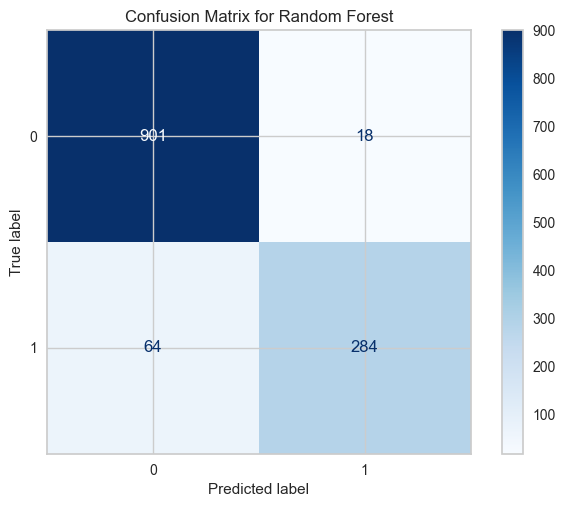

In [81]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [82]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

C-424144002_gt70     0.130479
C-263495000_m        0.128331
C-20565-8_normal     0.050619
C-424144002_50t70    0.043469
C-2069-3_normal      0.041641
C-72166-2_never      0.031144
C-789-8_normal       0.030916
C-1920-8_normal      0.030461
C-2857-1_normal      0.022604
C-4544-3_normal      0.021506
C-89579-7_normal     0.018474
C-1751-7_normal      0.016645
C-718-7_normal       0.016615
C-788-0_normal       0.016369
C-1975-2_normal      0.016296
C-21000-5_normal     0.016214
C-33914-3_normal     0.015174
C-785-6_normal       0.014282
C-2276-4_normal      0.013931
C-2028-9_normal      0.013609
dtype: float64


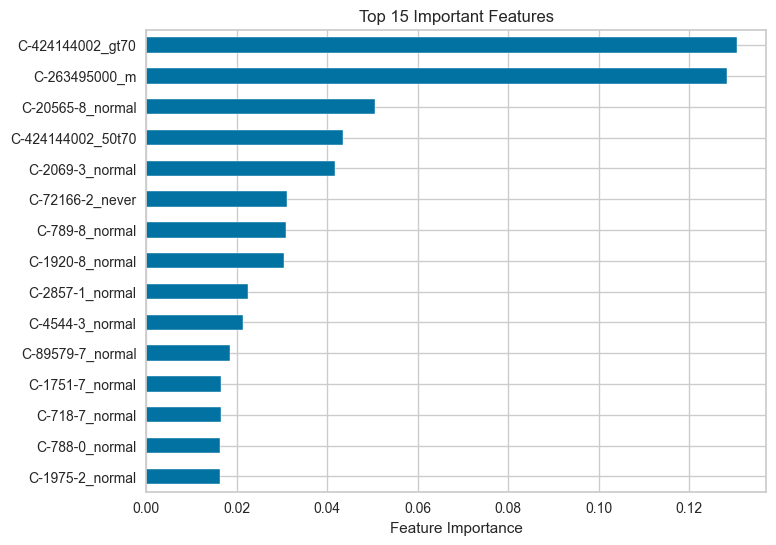

In [83]:
feature_importance.head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.show()

In [84]:
# Train/test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4,
    stratify=y
)

# Impute missing values
imputer = SimpleImputer(strategy="most_frequent")
X_train_imp = imputer.fit_transform(X_train1)
X_test_imp = imputer.transform(X_test1)

# Scale
scaler1 = MinMaxScaler()
X_train2 = scaler1.fit_transform(X_train_imp)
X_test2 = scaler1.transform(X_test_imp)

# Logistic regression
lrn = LogisticRegression(max_iter=2000)
lrn.fit(X_train2, y_train1)

# Predict on the SCALED data
y_train_pred1 = lrn.predict(X_train2)
y_pred1 = lrn.predict(X_test2)
y_prob1 = lrn.predict_proba(X_test2)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train1, y_train_pred1)
test_accuracy = accuracy_score(y_test1, y_pred1)
error = 1 - test_accuracy

print("Logistic Regression training accuracy:", train_accuracy)
print("Logistic Regression test error rate:", error)
print("Logistic Regression accuracy:", test_accuracy)
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test1, y_prob1))
print(confusion_matrix(y_test1, y_pred1))
print(classification_report(y_test1, y_pred1))

Logistic Regression training accuracy: 0.9268364928909952
Logistic Regression test error rate: 0.07692307692307687
Logistic Regression accuracy: 0.9230769230769231
Logistic Regression ROC-AUC: 0.9712936659728862
[[590  23]
 [ 42 190]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       613
           1       0.89      0.82      0.85       232

    accuracy                           0.92       845
   macro avg       0.91      0.89      0.90       845
weighted avg       0.92      0.92      0.92       845



C:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['C-79733001' 'C-789980' 'C-309845' 'C-448417001' 'C-171231001'
 'C-48387007' 'C-979092' 'C-82078001' 'C-60951000119105' 'C-200936003'
 'C-104173009' 'C-698423002' 'C-448813005' 'C-14152002' 'C-256277009'
 'C-288328004' 'C-200243' 'C-1940648' 'C-408512008' 'C-48333001'
 'C-727711' 'C-281790008' 'C-113076002' 'C-782576004' 'C-999998'
 'C-2284960' 'C-1483744' 'C-864706' 'C-1373463']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['C-79733001' 'C-789980' 'C-309845' 'C-448417001' 'C-171231001'
 'C-48387007' 'C-979092' 'C-82078001' 'C-60951000119105' 'C-200936003'
 'C-104173009' 'C-698423002' 'C-448813005' 'C-141520

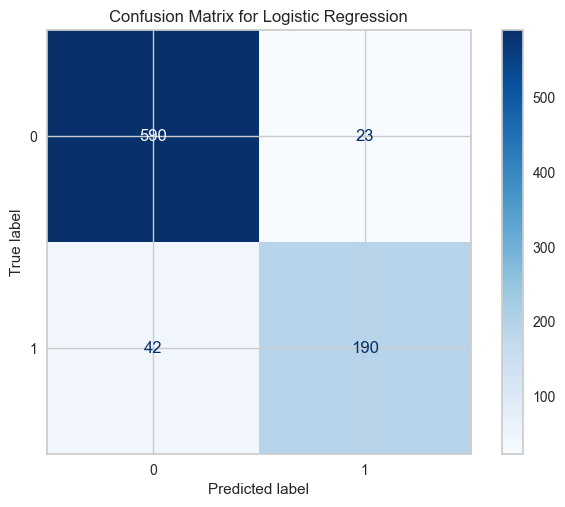

In [85]:
cm = confusion_matrix(y_test1, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

In [86]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("XGBoost Best Params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Accuracy: 0.9408050513022889
XGBoost ROC-AUC: 0.9823724563180869
[[892  27]
 [ 48 300]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       919
           1       0.92      0.86      0.89       348

    accuracy                           0.94      1267
   macro avg       0.93      0.92      0.92      1267
weighted avg       0.94      0.94      0.94      1267



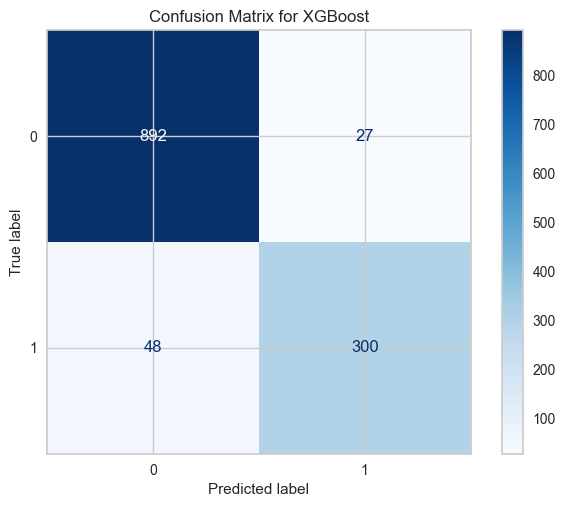

In [87]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for XGBoost")
plt.show()

In [88]:
param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20]
}

lgbm = LGBMClassifier(random_state=42)

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print("LightGBM Best Params:", grid_lgbm.best_params_)

best_lgbm = grid_lgbm.best_estimator_

y_pred_lgbm = best_lgbm.predict(X_test)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 810, number of negative: 2144
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 547
[LightGBM] [Info] Number of data points in the train set: 2954, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.274204 -> initscore=-0.973394
[LightGBM] [Info] Start training from score -0.973394
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Best Params: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
LightGBM Accuracy: 0.9337016574585635
LightGBM ROC-AUC: 0.9796489812764999
[[893  26]
 [ 58 290]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       919
           1       0.92      0.83      0.87       348

    acc

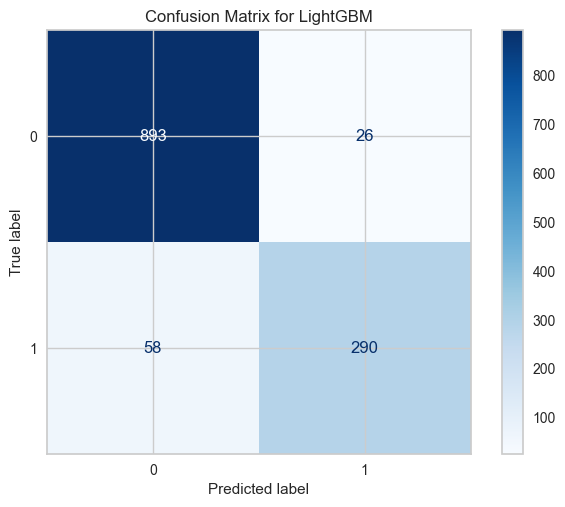

In [89]:
cm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for LightGBM")
plt.show()

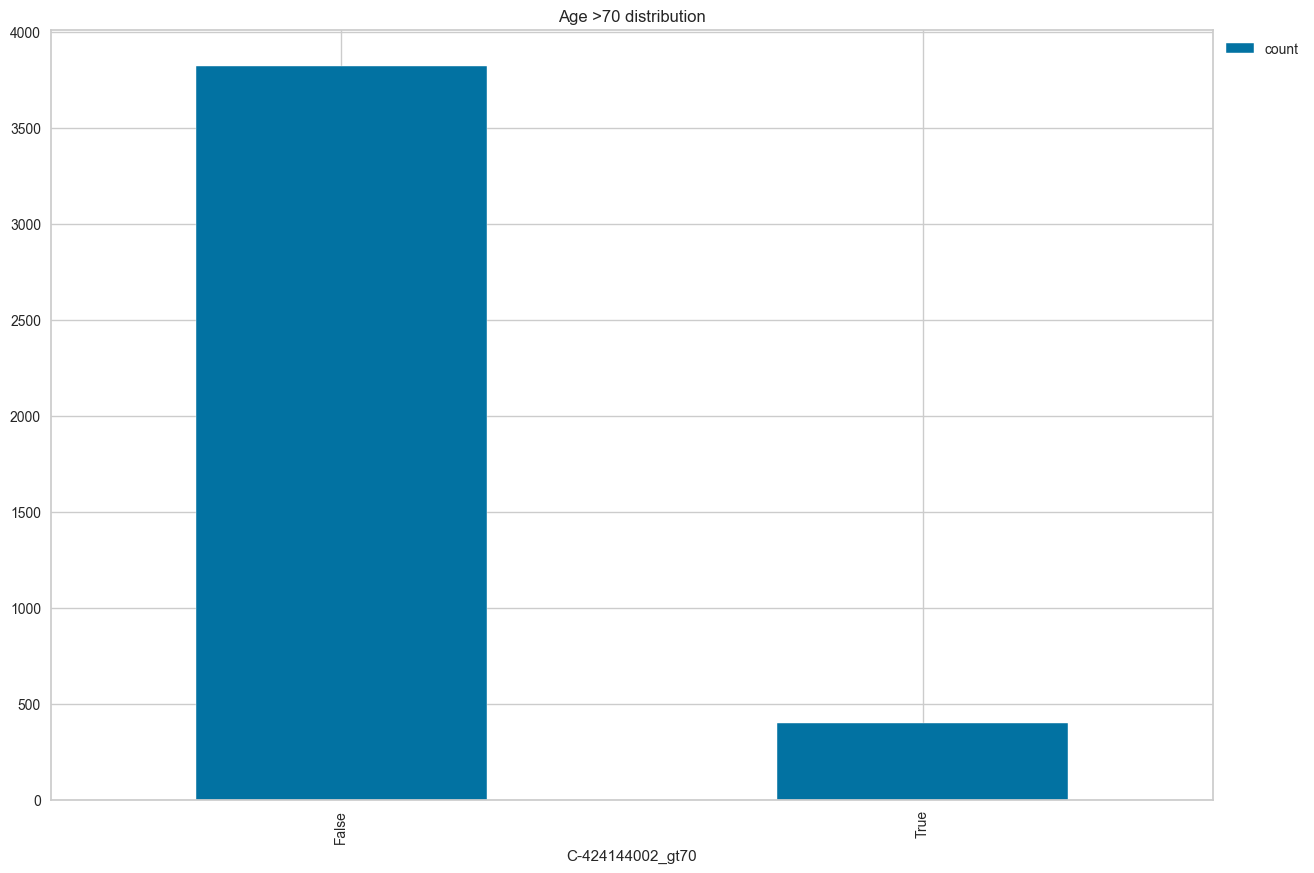

In [91]:
Over70Plot = X['C-424144002_gt70'].value_counts().plot(
    kind='bar',
    title="Age >70 distribution",
    figsize=(15,10)
)

Over70Plot.legend(loc='upper left', bbox_to_anchor=(1,1))

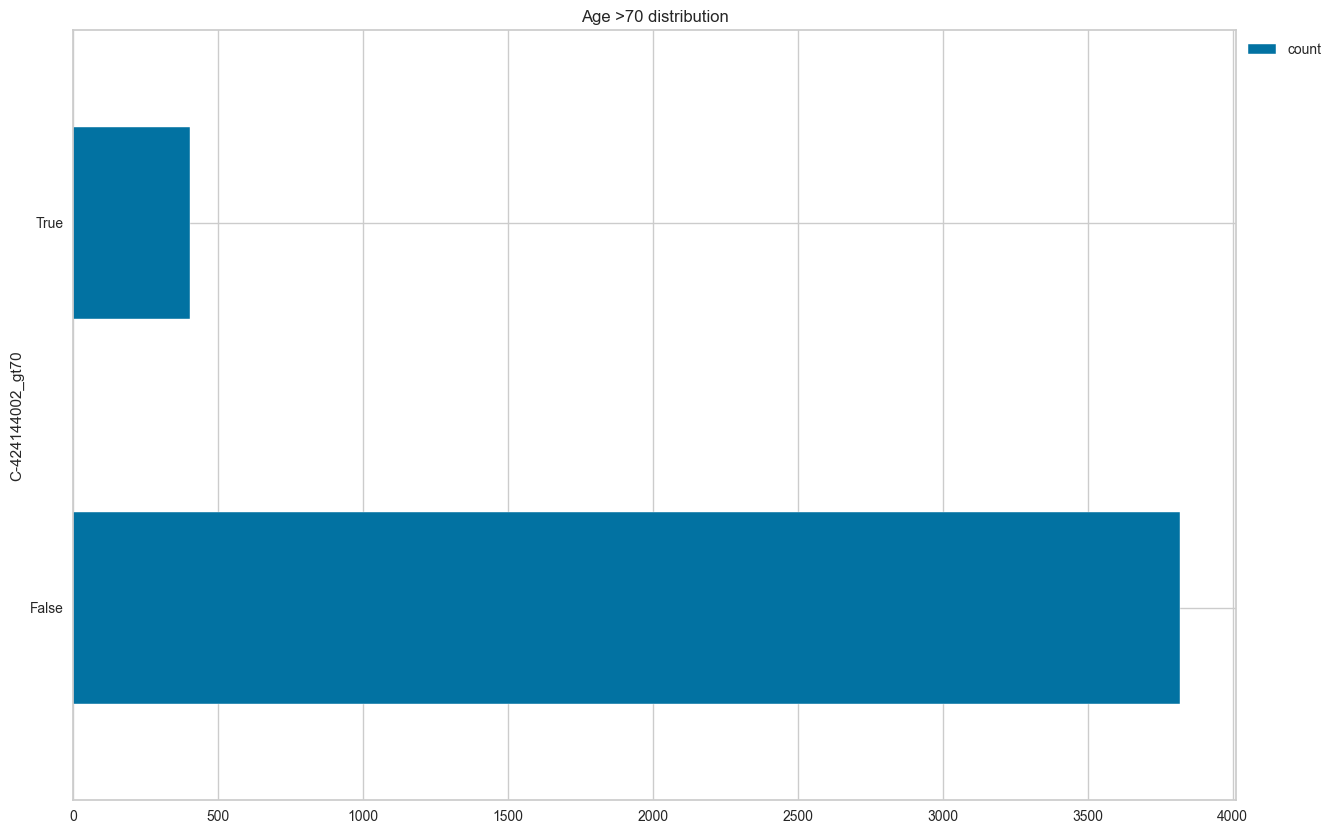

In [93]:
Over70Plot1 = X['C-424144002_gt70'].value_counts().plot(
    kind='barh',
    title="Age >70 distribution",
    figsize=(15,10)
)

Over70Plot1.legend(loc='upper left', bbox_to_anchor=(1,1))

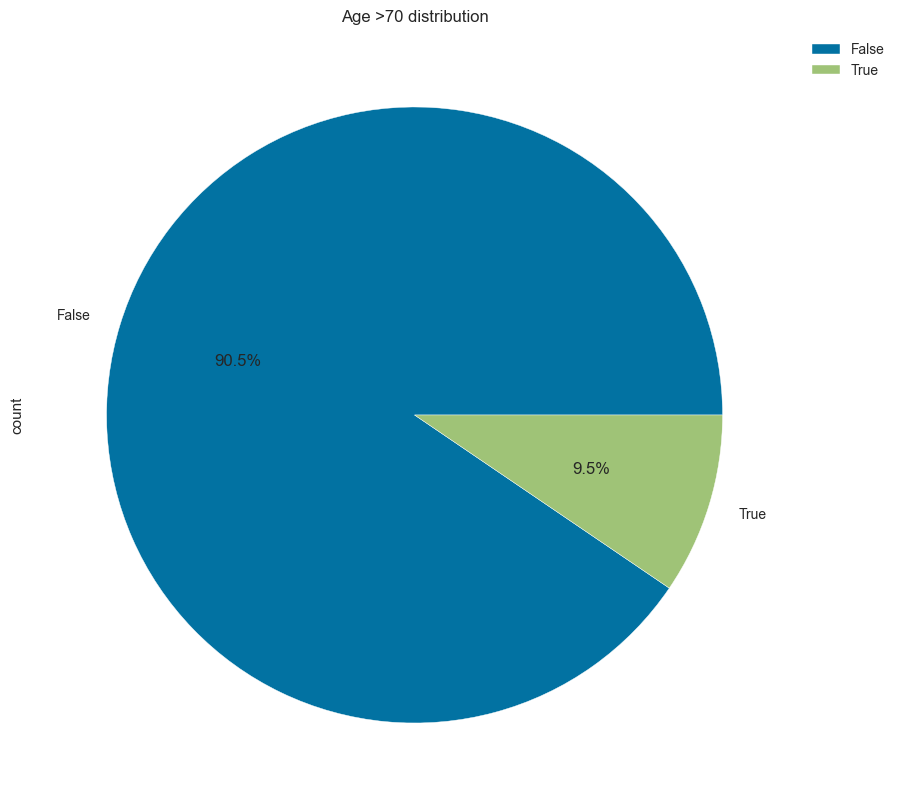

In [100]:
Over70Plot1 = X['C-424144002_gt70'].value_counts().plot(
    kind='pie',
    title="Age >70 distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

Over70Plot1.legend(loc='upper left', bbox_to_anchor=(1,1))

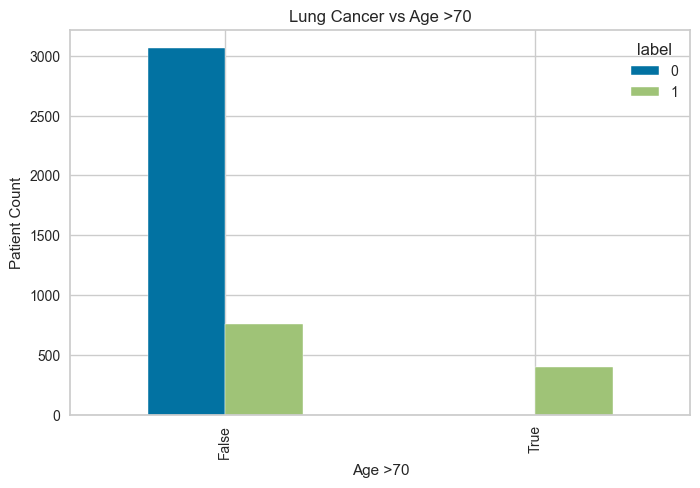

In [92]:
# Shows whether patients >70 have higher cancer prevalence
pd.crosstab(
    X['C-424144002_gt70'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs Age >70")
plt.xlabel("Age >70")
plt.ylabel("Patient Count")
plt.show()

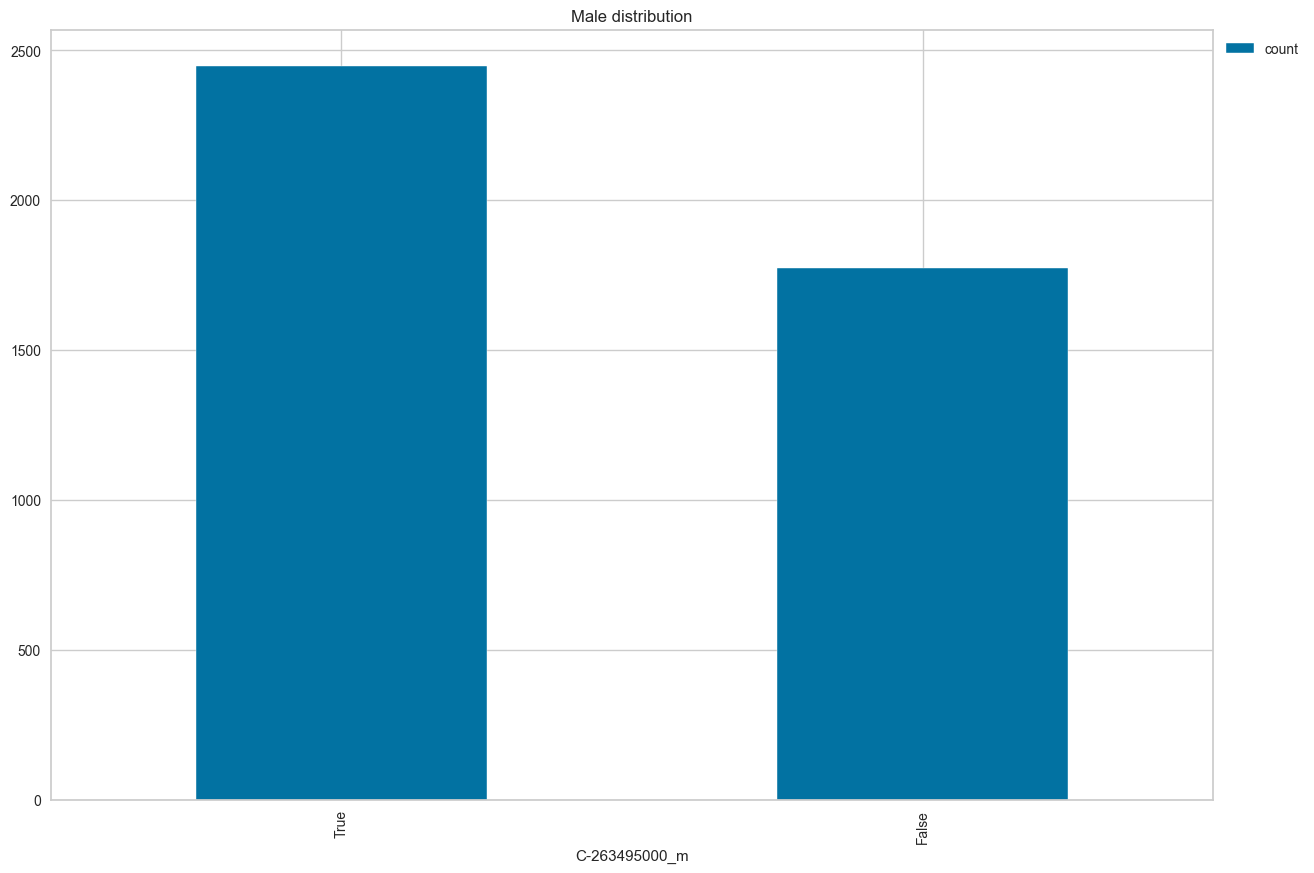

In [96]:
isMalePlot = X['C-263495000_m'].value_counts().plot(
    kind='bar',
    title="Male distribution",
    figsize=(15,10)
)

isMalePlot.legend(loc='upper left', bbox_to_anchor=(1,1))

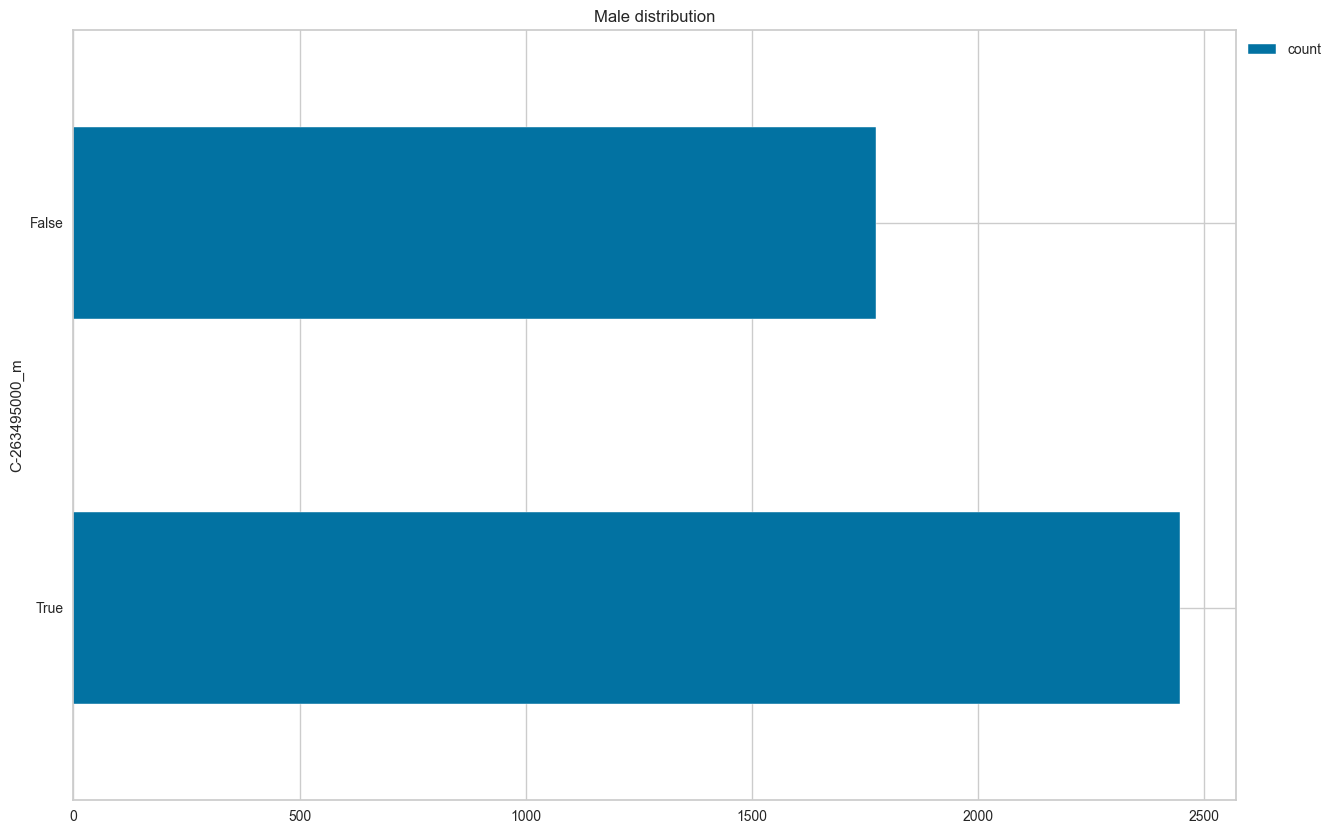

In [97]:
isMalePlot = X['C-263495000_m'].value_counts().plot(
    kind='barh',
    title="Male distribution",
    figsize=(15,10)
)

isMalePlot.legend(loc='upper left', bbox_to_anchor=(1,1))

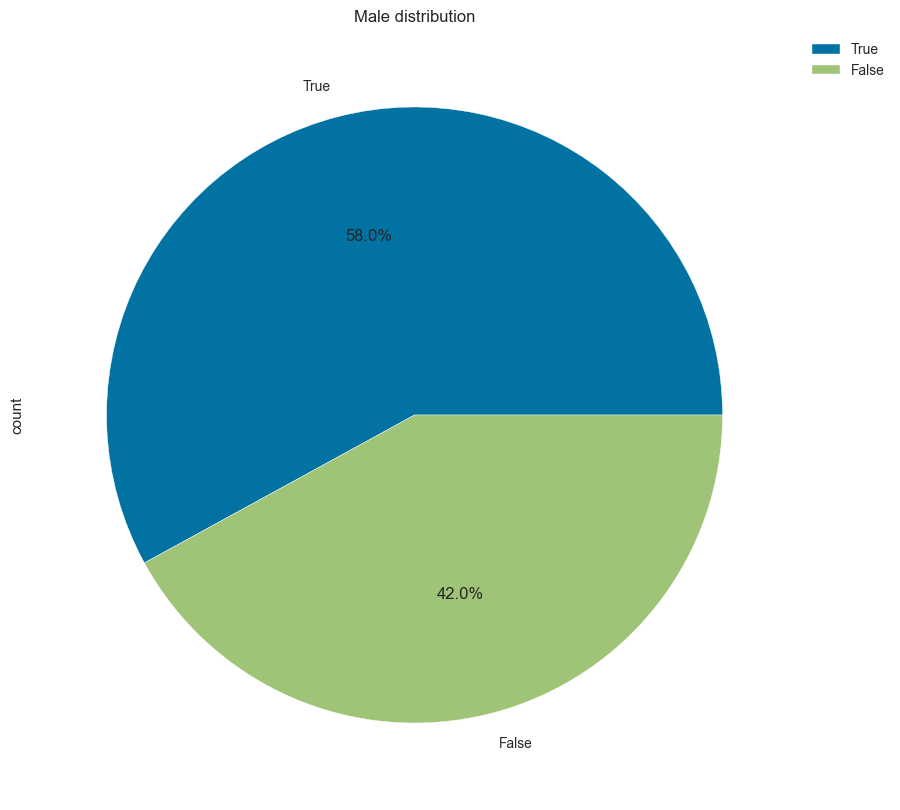

In [99]:
isMalePlot = X['C-263495000_m'].value_counts().plot(
    kind='pie',
    title="Male distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

isMalePlot.legend(loc='upper left', bbox_to_anchor=(1,1))
